## Parameter Estimation for M/M/c Priority Queue Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"

# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

### EDA

In [3]:
df = pd.read_csv("lax_passengers.csv")

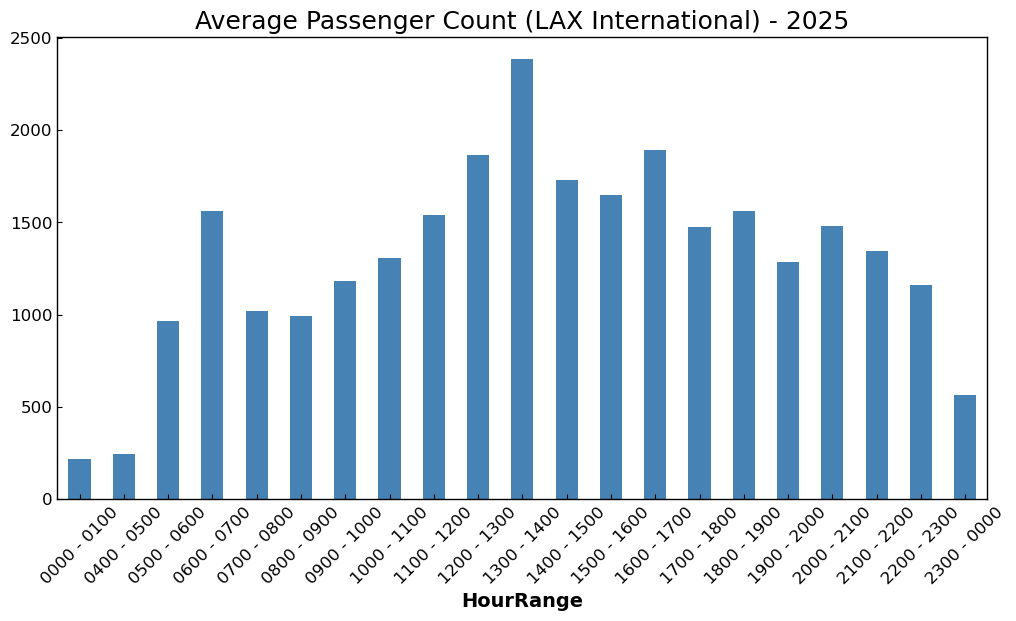

In [4]:
df.groupby("HourRange")["TotalPassengerCount"].mean().plot(
    kind="bar", figsize=(12, 6), color="steelblue"
)

plt.title("Average Passenger Count (LAX International) - 2025", fontsize=18)
plt.xticks(rotation=45)
plt.show()

### Arrival Rate ($\hat{\lambda}$) via MLE 

In [5]:
total_hours = df.shape[0]

total_passengers = df["TotalPassengerCount"].sum()
lambda_constant = total_passengers / total_hours

In [6]:
total_days = total_hours / 24
avg_passengers_per_day = total_passengers / total_days

In [ ]:
# units are passengers per minute
lambda_hat = lambda_constant / 60

print("Lambda Estiimate: {:.2f} passengers per hour".format(lambda_hat))

Lambda Estiimate: 23.60 passengers per hour


- The MLE estimate for the Poisson distribution parameter is just the average of the data.
- Our estimate of the arrival rate is $\hat{\lambda} = 23.6$ passengers per hour.
- We can plug this into our exponential distribution to get a distribution for interarrival times.
- Source
    - https://awt.cbp.gov/Report

### Service Time Approximation ($\hat{\mu}$)

The idea of Erlang C is that we give it an average wait time and arrival rate it backs out the service rate $\mu$ numerically. Find the value of $\mu$ such that the theoretical average wait time $W_q$ matches the observed average wait time $W_q^{obs}$. 

Assume
- We have to assume the data recorded by the TSA are for M/M/c queues. 
- This means that passport control lines are Poisson arrivals, exponential service times, and $c$ servers.
- Passport control vs security lines are not one-to-one but we have to use the data given.

In [112]:
df.head()

,HourRange,TotalPassengerCount,AverageWait
0,0500 - 0600,1098,23
1,0600 - 0700,3104,38
2,0700 - 0800,460,49
3,0800 - 0900,2247,42
4,0900 - 1000,1510,48


In [136]:
Wq_est = df["AverageWait"].mean()
Wq_est

25.703385416666666

In [137]:
import scipy.special as sp
from scipy.optimize import minimize_scalar

# Parameters
# arrival rate (passengers per minute)
lam = lambda_hat
# average wait time in minutes
# number of servers
Wq_target = Wq_est
c = 12

- We set `lam` to our observed estimate of the arrival rate ($\hat{\lambda}$).
- We set `Wq_target` to the observed averaage wait time in minutes.
- We set the number of servers $c$ to be 12. This is the maximum number of servers that we computed from the Lockheed 
Martin data.


In [ ]:
def erlang_c(c, rho):
    """implements Equation (1) below

    Args:
        c (_type_): number of servers
        rho (_type_): lambda / (c * mu), where mu is the service rate
    """
    # system unstable,
    # keep because I kept getting NaN errors
    if rho >= 1:
        return 1.0
    # Erlang C formula
    # See equation below
    numer = (rho * c) ** c / (sp.factorial(c) * (1 - rho))
    denom = sum((rho * c) ** n / sp.factorial(n) for n in range(c)) + numer
    return numer / denom


def wait_time(mu):
    if mu <= lam / c:  # system unstable
        return 1e6
    # server utilization
    rho = lam / (c * mu)
    C = erlang_c(c, rho)

    # Wait time in queue
    Wq = C / (c * mu - lam)

    # Minimize the difference between theoretical Wq and observed
    return abs(Wq - Wq_target)


# Wq is the average wait time in queue
res = minimize_scalar(wait_time, bounds=(lam / c + 0.001, 2), method="bounded")

if res.success:
    mu_est = res.x
    print(f"Estimated service rate μ: {mu_est:.4f} passengers/min")
    print(f"Estimated service time: {1 / mu_est:.2f} minutes/passenger")
else:
    print("Optimization failed.")

Estimated service rate μ: 1.9701 passengers/min
Estimated service time: 0.51 minutes/passenger


#### Equations




**Equation 1**: Erlang's C

Let $\rho = \frac{\lambda}{c \mu}$, the server utilization. The Erlang-C formula gives us the probability that an arriving customer is forced to join the queue (all servers are occupied), which is given by:

$$
C(c, p) = \frac{(\frac{(c \rho)^c}{c!}) (\frac{1}{1-\rho})}{\sum_{k=0}^{c-1} \frac{(c \rho)^k}{k!} + \frac{(c \rho)^c}{c! (1 - \rho)}}
$$


**Equation 2**: 

The average number of customers in the system is given by 

$$
L = L_q + L_s
$$

where $L_q$ is the average number of customers in the queue and $L_s$ is the average number of customers in service.

Little's Law

$$
L = \lambda W
$$
- L: the average number of customers in the system
- $\lambda$: the arrival rate
- $W$: the average time a customer spends in the system
- This tells us that the long-term average number of customers in a stable system is equal to the long-term average arrival rate multiplied by the long-term average time a customer spends in the system.
- Formula works for subsystems as well, such as the queue.

$$
W_q = \frac{L_q}{\lambda} = \frac{C(c, \rho)}{c\mu - \lambda}
$$


Source
- https://en.wikipedia.org/wiki/M/M/c_queue
- https://en.wikipedia.org/wiki/Little%27s_law

### Number of Servers Estimation ($c$)

In [ ]:
def calc_and_print_num_servers(df, title=""):
    # Make the assumption that half of staff are allocated to
    # security screening, hence the division by 2
    df["tsa_per_lane"] = df["Staff"] / df["Lanes"] / 2
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    mean_weekday = df["tsa_per_lane"].mean()
    min_weekday = df["tsa_per_lane"].min()
    max_weekday = df["tsa_per_lane"].max()

    print(f"{title} Staffing Statistics")
    print(f"  Mean TSA per lane: {mean_weekday:.2f}")
    print(f"  Min TSA per lane: {min_weekday:.2f}")
    print(f"  Max TSA per lane: {max_weekday:.2f}")

In [39]:
calc_and_print_num_servers(pd.read_csv("./lockheed_staff_weekday.csv"), title="Weekday")
calc_and_print_num_servers(pd.read_csv("./lockheed_staff_weekend.csv"), title="Weekend")

Weekday Staffing Statistics
  Mean TSA per lane: 4.50
  Min TSA per lane: 2.50
  Max TSA per lane: 11.67
Weekend Staffing Statistics
  Mean TSA per lane: 4.52
  Min TSA per lane: 2.69
  Max TSA per lane: 12.00


- It is very unclear what Lockhheed Martin's data means when they mention staff and lines.
- The data seems like it's for the entire airport not just a specific terminal.
- The size of the airport is also not clear.
- From anecdotal experience, the number of servers at a security checkpoint is around 4-5 with around 3 points of entry. The max of 12 servers from above seems to be a reasonable estimate.